# Aggregation — listing-level table

Builds the aggregation output for the pipeline, at the grain agreed with the team
(Yusuke, 2026-09-08): **one row per Airbnb listing**, with neighbourhood-level crime,
IPTU and POI attached as columns of the listing's **distrito**.

Spatial unit and join routes were fixed by the feasibility study — see
`obsidian-vault/09 - Spatial Aggregation.md` and
`notebooks/spatial_aggregation_study.ipynb`.

**Outputs** (git-ignored):
- `data/processed/listings_aggregated.csv` — 1 row / listing (modeling table).
- `data/processed/distrito_features.csv` — 1 row / distrito (EDA / maps).

**Inputs**: `data/raw/{Airbnb,IPTU-SP}/…`, `data/processed/ISP/…`, and the cached
GeoSampa / lookup files in `data/external/` produced by the study notebook.

In [1]:
import warnings, zipfile, unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RAW = Path("../data/raw")
EXT = Path("../data/external")
PROC = Path("../data/processed"); PROC.mkdir(parents=True, exist_ok=True)

def norm(s):
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode()
    return " ".join(s.upper().split())

## Distrito boundaries

In [2]:
dist = gpd.read_file(EXT / "distrito_municipal.geojson")[
    ["nm_distrito_municipal", "nm_regiao_05", "qt_area_metro", "geometry"]]
dist["geometry"] = dist.geometry.make_valid()
dist["distrito"] = dist["nm_distrito_municipal"].map(norm)
D = set(dist["distrito"])
print(f"{len(dist)} distritos")

96 distritos


## Crime → distrito

Crosswalk from the study (`dp_to_distrito.csv`): bounded geocoding of the 94 DP
neighbourhood names + 9 hand-mapped. The ~25 distritos with no DP get the value of
their **nearest** distrito that does — flagged in `crime_source`.

> Known gap: the DP crosswalk still needs a full manual review by the team, and the
> imputation is a placeholder. Tracked in `09 - Spatial Aggregation.md`.

In [3]:
cr = pd.read_csv("../data/processed/ISP/dados_criminais_sao_paulo_2025.csv")
cr["2025"] = cr["2025"].fillna(0)
cr["bairro"] = cr["DP"].str.split(" - ").str[-1].str.strip()
occ = cr[~cr["NATUREZA2"].str.startswith("Nº DE VÍTIMAS")].copy()
dp_total = occ.groupby("bairro")["2025"].sum()

xw = pd.read_csv(EXT / "dp_to_distrito.csv")
MANUAL = {"Jardim Mirna": "CAMPO GRANDE", "Parque Santo Antônio": "JARDIM SAO LUIS",
          "Parque São Rafael": "SAO RAFAEL", "Vale do Aricanduva": "ARICANDUVA",
          "Vila Alpina": "SAPOPEMBA", "Vila Diva": "ARICANDUVA",
          "Vila Pereira Barreto": "VILA GUILHERME", "Vila Rica": "JARAGUA",
          "Vila Santa Maria": "TREMEMBE"}
xw["distrito"] = xw.apply(lambda r: MANUAL.get(r["bairro"], r["distrito"]), axis=1)
xw["review_status"] = np.where(xw["bairro"].isin(MANUAL), "manual-guess", "geocoded")
xw = xw.dropna(subset=["distrito"])
xw["crime_total"] = xw["bairro"].map(dp_total)
xw[["bairro", "distrito", "review_status"]].to_csv(EXT / "dp_distrito_crosswalk.csv", index=False)

crime_direct = xw.groupby("distrito")["crime_total"].mean()

have = dist[dist["distrito"].isin(crime_direct.index)].to_crs(31983)
miss = dist[~dist["distrito"].isin(crime_direct.index)].to_crs(31983)
have_c = have.assign(c=have.geometry.centroid, crime=have["distrito"].map(crime_direct))
imp = {r["distrito"]: have_c.assign(d=have_c["c"].distance(r.geometry.centroid))
                            .nsmallest(1, "d")["crime"].iat[0]
       for _, r in miss.iterrows()}

crime = pd.concat([crime_direct, pd.Series(imp)]).rename("crime_occurrences_2025")
crime_source = pd.Series({**{d: "dp-direct" for d in crime_direct.index},
                          **{d: "nearest-distrito-imputed" for d in imp}}, name="crime_source")
print(f"{len(crime_direct)} distritos com DP direto, {len(imp)} imputados por vizinho")

71 distritos com DP direto, 25 imputados por vizinho


## IPTU-SP → distrito

Route from the study: `numero_contribuinte`[:6] (fiscal sector+block) → `quadra_fiscal`
→ distrito (99.94% of rows). Residential only.

> The value is the **fiscal** venal value per m² (`valor_terreno + valor_construcao`) /
> `area_construida` — well below market price. Level needs FipeZAP calibration; the
> spatial join is settled.

In [4]:
q2d = pd.read_csv(EXT / "quadra_to_distrito.csv", dtype={"sq": str}).set_index("sq")["distrito"]
it = pd.read_csv(zipfile.ZipFile(RAW / "IPTU-SP" / "iptu_2025.zip").open("iptu_2025.csv"),
                 low_memory=False,
                 usecols=["numero_contribuinte", "valor_construcao", "valor_terreno",
                          "area_construida", "finalidade_imovel"],
                 dtype={"numero_contribuinte": str})
it["distrito"] = it["numero_contribuinte"].str.zfill(11).str[:6].map(q2d)

RES = ["Residência", "Apartamento Em Condomínio",
       "Residência E Outro Uso (Predominância Residencial)",
       "Prédio De Apartamento, Não Em Condomínio, De Uso Exclusivamente Residencial",
       "Flat Residencial Em Condomínio"]
itr = it[it["finalidade_imovel"].isin(RES) & it["distrito"].notna()].copy()
itr["venal_m2"] = (itr["valor_terreno"] + itr["valor_construcao"]) / itr["area_construida"].replace(0, np.nan)
itr = itr[(itr["venal_m2"] > 50) & (itr["venal_m2"] < 200000)]
iptu = itr.groupby("distrito").agg(iptu_venal_m2_median=("venal_m2", "median"),
                                   iptu_n_imoveis=("venal_m2", "size"))
print(f"{len(iptu)}/96 distritos")

96/96 distritos


## POI → distrito (OSM placeholder)

From the study. Placeholder until Google Places is collected.

In [5]:
poi = pd.read_csv(EXT / "poi_by_distrito.csv").set_index("distrito")[["poi_n", "poi_per_km2"]]
poi.columns = ["poi_osm_n", "poi_osm_per_km2"]

## Distrito feature table

In [6]:
feat = (dist.set_index("distrito")[["nm_regiao_05", "qt_area_metro"]]
            .rename(columns={"nm_regiao_05": "regiao", "qt_area_metro": "area_m2"})
            .join(crime).join(crime_source).join(iptu).join(poi))
feat[["poi_osm_n", "poi_osm_per_km2"]] = feat[["poi_osm_n", "poi_osm_per_km2"]].fillna(0)
feat.to_csv(PROC / "distrito_features.csv")
print(feat.shape, "| nulls:", feat.isna().sum().sum())
feat.head()

(96, 8) | nulls: 0


,regiao,area_m2,crime_occurrences_2025,crime_source,iptu_venal_m2_median,iptu_n_imoveis,poi_osm_n,poi_osm_per_km2
distrito,,,,,,,,
RIO PEQUENO,Oeste,9657007.38,3683.0,nearest-distrito-imputed,60.242857,3364,0.0,0.000000
CIDADE TIRADENTES,Leste,14939046.96,4532.0,dp-direct,67.875000,9673,4.0,0.267755
JARDIM SAO LUIS,Sul,26047523.11,8925.5,dp-direct,53.645833,3816,3.0,0.115174
PONTE RASA,Leste,6596680.61,4762.0,dp-direct,60.000000,1967,1.0,0.151591
LIBERDADE,Centro,3651129.57,6616.0,dp-direct,91.455696,26510,46.0,12.598841


## Listing-level table — the modeling grain

`listings.csv` left-joined to the distrito features on `distrito`
(`neighbourhood_cleansed`, validated 100% against point-in-polygon in the study).

In [7]:
li = pd.read_csv(RAW / "Airbnb" / "listings.csv", low_memory=False)
li["distrito"] = li["neighbourhood_cleansed"].map(norm)
li["price_num"] = li["price"].replace(r"[\$,]", "", regex=True).astype(float)

COLS = ["id", "name", "neighbourhood_cleansed", "neighbourhood_group_cleansed",
        "latitude", "longitude", "room_type", "property_type", "accommodates",
        "bedrooms", "bathrooms_text", "beds", "price_num", "minimum_nights",
        "availability_365", "number_of_reviews", "review_scores_rating",
        "estimated_occupancy_l365d", "estimated_revenue_l365d", "distrito"]
COLS = [c for c in COLS if c in li.columns]

lm = li[COLS].merge(feat.reset_index(), on="distrito", how="left")
lm.to_csv(PROC / "listings_aggregated.csv", index=False)
print(f"{lm.shape[0]:,} listings x {lm.shape[1]} cols | "
      f"distrito features attached: {lm['crime_occurrences_2025'].notna().mean()*100:.1f}%")
lm.head(4)

42,354 listings x 28 cols | distrito features attached: 100.0%


,id,name,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,room_type,property_type,accommodates,bedrooms,...,estimated_revenue_l365d,distrito,regiao,area_m2,crime_occurrences_2025,crime_source,iptu_venal_m2_median,iptu_n_imoveis,poi_osm_n,poi_osm_per_km2
0,4917,Resort Condo Near Av. Paulista,Vila Mariana,Vila Mariana,-23.57419,-46.63973,Entire home/apt,Entire condo,4,2.0,...,27022.0,VILA MARIANA,Sul,8597789.80,6485.0,dp-direct,94.270000,51379,18.0,2.093561
1,54614,Nice area/Cozy flat/ Building rooftop pool,Santa Cecilia,Se,-23.54153,-46.65362,Entire home/apt,Entire rental unit,3,1.0,...,17342.0,SANTA CECILIA,Centro,3759528.16,8049.0,dp-direct,112.984615,37554,8.0,2.127927
2,82935,Oscar Freire - Hospital das Clínicas e Nu Bank,Jardim Paulista,Pinheiros,-23.55699,-46.67436,Private room,Private room in rental unit,1,NaN,...,16686.0,JARDIM PAULISTA,Oeste,6186611.40,8742.0,dp-direct,122.450841,47758,20.0,3.232787
3,90394,Private Room in Vila Mariana Sao Paulo,Vila Mariana,Vila Mariana,-23.59164,-46.64807,Private room,Private room in condo,1,NaN,...,24300.0,VILA MARIANA,Sul,8597789.80,6485.0,dp-direct,94.270000,51379,18.0,2.093561


In [8]:
# sanity: one distrito, many listings, same neighbourhood-level columns
sample = lm[lm["distrito"] == "PINHEIROS"]
print(f"PINHEIROS: {len(sample)} listings, "
      f"crime={sample['crime_occurrences_2025'].nunique()} unique value(s), "
      f"iptu={sample['iptu_venal_m2_median'].nunique()} unique value(s)")
lm.groupby("crime_source").size()

PINHEIROS: 2838 listings, crime=1 unique value(s), iptu=1 unique value(s)


crime_source
dp-direct                   28279
nearest-distrito-imputed    14075
dtype: int64

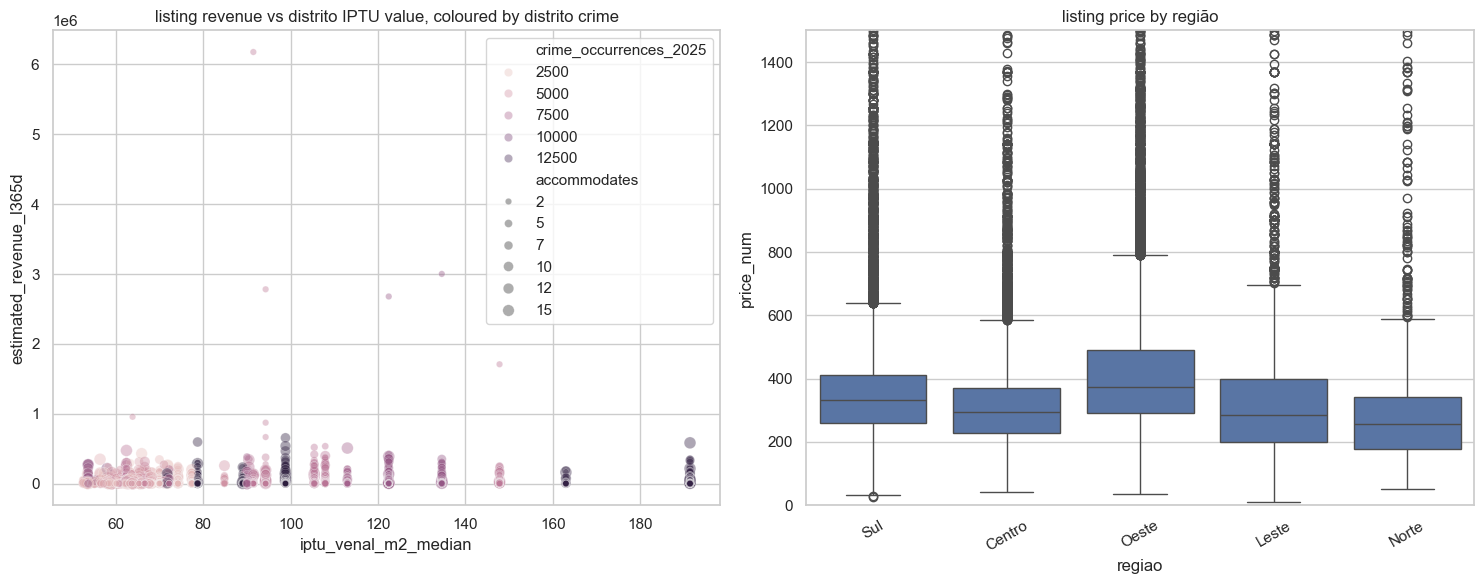

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=lm[lm["estimated_revenue_l365d"] > 0],
                x="iptu_venal_m2_median", y="estimated_revenue_l365d",
                hue="crime_occurrences_2025", size="accommodates",
                alpha=0.4, ax=axes[0], legend="brief")
axes[0].set_title("listing revenue vs distrito IPTU value, coloured by distrito crime")
sns.boxplot(data=lm, x="regiao", y="price_num", ax=axes[1])
axes[1].set_ylim(0, 1500); axes[1].set_title("listing price by região"); axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## Output summary

| File | Grain | Rows | Use |
|---|---|---|---|
| `data/processed/listings_aggregated.csv` | 1 listing | 42,354 | modeling table (hedonic revenue, score) |
| `data/processed/distrito_features.csv` | 1 distrito | 96 | EDA, maps, Phase 2 spatial checks |

**Column groups in `listings_aggregated.csv`:**
- listing attributes — `room_type`, `accommodates`, `bedrooms`, `price_num`,
  `estimated_revenue_l365d`, `estimated_occupancy_l365d`, reviews, availability…
- distrito context — `regiao`, `iptu_venal_m2_median`, `crime_occurrences_2025`
  (+ `crime_source`), `poi_osm_per_km2`.

**Still open before this is score-ready** (see `09 - Spatial Aggregation.md`):
crime crosswalk manual review + a real imputation rule; population by distrito for
crime rates; Google Places for POI; FipeZAP deflation of the IPTU value; property-profile
clustering.